# N-Gram Analysis with TF-IDF

This notebook performs N-gram analysis using TF-IDF weighting instead of raw frequency counting.
TF-IDF assigns higher scores to N-grams that are important within specific documents but not overly common across the entire corpus.

## 1. Setup & Installation

In [98]:
# Install required libraries
!pip install nltk Sastrawi matplotlib seaborn pandas scikit-learn -q


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [99]:
import pandas as pd
import numpy as np
import re
import string
from collections import Counter

import nltk
from nltk.util import ngrams
from nltk.tokenize import word_tokenize
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

from sklearn.feature_extraction.text import TfidfVectorizer

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully.")

All libraries loaded successfully.


## 2. Load Dataset

In [102]:
path = "../preprocessed/dataset_preprocessed_bert.csv"
df = pd.read_csv(path)

print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Columns: {list(df.columns)}")
print()
df.head()

Dataset shape: 999 rows, 6 columns
Columns: ['url', 'judul', 'konten', 'manual sentiment', 'konten_length', 'konten_preprocessed']



,url,judul,konten,manual sentiment,konten_length,konten_preprocessed
0,https://www.cnbcindonesia.com/research/2025012...,Trump Sebar Exceutive Order: Emang Semengerika...,"Jakarta, CNBC Indonesia -Amerika Serikat (AS) ...",Positive,8328,jakarta cnbc indonesia amerika serikat as seca...
1,https://www.cnbcindonesia.com/research/2025012...,"Alasan Rupiah 'Berpesta' di Pelantikan Trump, ...","Jakarta, CNBC Indonesia -Nilai tukar rupiah te...",Positive,2925,jakarta cnbc indonesia nilai tukar rupiah terh...
2,https://www.cnbcindonesia.com/research/2025012...,"Trump Beri Kabar Baik, Saatnya Menunggu Dolar ...","Jakarta, CNBC Indonesia-Pasar keuangan Indones...",Positive,13102,jakarta cnbc indonesia pasar keuangan indonesi...
3,https://www.cnbcindonesia.com/research/2025030...,"IHSG Merah Lagi, Begini Penjelasan dari Analis...","Jakarta, CNBC Indonesia -Indeks Harga Saham Ga...",Negative,5158,jakarta cnbc indonesia indeks harga saham gabu...
4,https://indodax.com/academy/bitcoin-200k-predi...,Bernstein: Bitcoin Bisa Naik 2x Lipat! Target ...,HargaBitcoin(BTC)pernah melewati angka terting...,Positive,4767,hargabitcoin btc pernah melewati angka terting...


In [103]:
# Quick data overview
print("DATASET INFO")
print(f"Total articles   : {len(df)}")
print(f"Missing 'Konten' : {df['konten_preprocessed'].isna().sum()}")
print()

DATASET INFO
Total articles   : 999
Missing 'Konten' : 0



## 3. Article Selection

In [104]:
# ADJUST THIS: Choose your selection mode
SELECTION_MODE = "all"  # Options: "by_number", "by_sentiment", "all"

# --- If SELECTION_MODE = "by_number" ---
ARTICLE_NUMBERS = [9]  # <-- Change these numbers

# --- If SELECTION_MODE = "by_sentiment" ---
TARGET_SENTIMENT = "positif"  # <-- Change this label

if SELECTION_MODE == "by_number":
    selected_df = df[df['No'].isin(ARTICLE_NUMBERS)].copy()
    print(f"Selected {len(selected_df)} article(s) by number: {ARTICLE_NUMBERS}")

elif SELECTION_MODE == "by_sentiment":
    selected_df = df[df['Sentiment'].str.lower() == TARGET_SENTIMENT.lower()].copy()
    print(f"Selected {len(selected_df)} article(s) with sentiment: '{TARGET_SENTIMENT}'")

elif SELECTION_MODE == "all":
    selected_df = df.copy()
    print(f"Selected ALL {len(selected_df)} articles")

else:
    raise ValueError(f"Invalid SELECTION_MODE: '{SELECTION_MODE}'. Use 'by_number', 'by_sentiment', or 'all'.")

# Drop rows with empty content
selected_df = selected_df.dropna(subset=['konten_preprocessed'])
print(f"Articles with valid content: {len(selected_df)}")
print()

Selected ALL 999 articles
Articles with valid content: 999



## 4. Text Preprocessing (Bahasa Indonesia)

Preprocessing steps:
1. **Lowercase** all text
2. **Remove publisher/media noise** (leaked bylines, boilerplate from scraping)
3. **Remove URLs, HTML tags, numbers, punctuation**
4. **Remove Indonesian stopwords** using Sastrawi
5. **Tokenize** into individual words
6. *(Optional)* **Stemming** using Sastrawi Indonesian stemmer

Sastrawi is used because it is specifically built for Bahasa Indonesia, unlike NLTK's default English stopwords.

In [127]:
USE_STEMMING = False  # Set True to enable stemming

# Initialize Sastrawi tools
stopword_factory = StopWordRemoverFactory()
indonesian_stopwords = set(stopword_factory.get_stop_words())

# Add custom stopwords if needed (common filler words in articles)
custom_stopwords = {
    'yang', 'dan', 'di', 'dari', 'untuk', 'pada', 'dengan',
    'ini', 'itu', 'ke', 'dalam', 'adalah', 'juga', 'tidak',
    'akan', 'ada', 'atau', 'bisa', 'sudah', 'lebih', 'oleh',
    'hal', 'saat', 'dapat', 'telah', 'mereka', 'saya', 'kami',
    'kita', 'hanya', 'seperti', 'tentang', 'antara', 'lain',
    'maka', 'jika', 'bagi', 'pun', 'lagi', 'masih', 'ia',
    'dia', 'anda', 'kata', 'ujar', 'ucap', 'tutur', 'sebut'
}
all_stopwords = indonesian_stopwords.union(custom_stopwords)

# ---- Publisher / media noise phrases to remove ----
# These are publisher names, bylines, and boilerplate text that
# leak into article content from headers/footers during scraping.
# Add more as needed when you spot anomalies in TF-IDF results.
PUBLISHER_NOISE_PHRASES = [
    # --- International media ---
    'bloomberg news bloomberg', 'bloomberg news', 'bloomberg com',
    'reuters thomson reuters', 'thomson reuters', 'reuters com',
    'associated press', 'the associated press',
    'agence france presse', 'afp', 'bloomberg technoz jakarta',
    'ursula von der', 'berita terbaru hari', 'sindonews berita terbaru',
    'channel sindonews berita', 'whatsapp channel sindonews', 'konten melakukan crawling',
    'von der leyen', 'continue with content', 'gambas video cnn', 'federal reserve the', 'reserve the fed',
    # --- Indonesian media ---
    'cnbc indonesia', 'cnbc com', 'cnnindonesia com', 'cnn indonesia',
    'kompas com', 'kompas tv', 'tribunnews com', 'tribun news',
    'detik com', 'detikfinance', 'detikcom', 'detiknews',
    'liputan6 com', 'liputan enam', 'suara com',
    'tempo co', 'tempo interaktif', 'majalah tempo',
    'kontan co id', 'kontan online',
    'bisnis com', 'bisnis indonesia',
    'katadata co id', 'katadata',
    'idnfinancials com', 'idn financials',
    'antara news', 'kantor berita antara', 'antaranews com',
    'okezone com', 'sindonews com', 'sindo news',
    'viva co id', 'vivanews', 'merdeka com',
    'republika co id', 'republika online',
    'tirto id', 'kumparan com', 'medcom id',
    'investor daily', 'investor id', 'market bisnis com',
    'inews id', 'jpnn com', 'rmol id',
    # --- Common byline / boilerplate noise ---
    'baca juga', 'baca selengkapnya', 'baca artikel',
    'simak juga', 'simak selengkapnya',
    'sumber gambar', 'foto ilustrasi', 'foto dok',
    'editor', 'pewarta', 'kontributor', 'penulis',
    'hak cipta', 'all rights reserved', 'copyright',
    'unduh aplikasi', 'download aplikasi',
    'follow', 'subscribe', 'berlangganan',
    'share', 'bagikan', 'komentar',
    'advertisement', 'iklan', 'promoted content',
]

# Sort longest first so longer phrases get removed before shorter substrings
PUBLISHER_NOISE_PHRASES = sorted(PUBLISHER_NOISE_PHRASES, key=len, reverse=True)

print(f"Publisher noise phrases loaded: {len(PUBLISHER_NOISE_PHRASES)}")

if USE_STEMMING:
    stemmer_factory = StemmerFactory()
    stemmer = stemmer_factory.createStemmer()
    print("Stemmer initialized (this may take a moment).")

print(f"Total stopwords loaded: {len(all_stopwords)}")

Publisher noise phrases loaded: 94
Total stopwords loaded: 129


In [128]:
def preprocess_text(text):
    if not isinstance(text, str):
        return ""

    # Step 1: Lowercase
    text = text.lower()

    # Step 2: Remove publisher/media noise phrases
    # Removes leaked publisher names, bylines, boilerplate from scraping
    for phrase in PUBLISHER_NOISE_PHRASES:
        text = text.replace(phrase, ' ')

    # Step 3: Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', ' ', text)

    # Step 4: Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)

    # Step 5: Remove numbers
    text = re.sub(r'\d+', ' ', text)

    # Step 6: Remove punctuation and special characters
    text = re.sub(r'[^\w\s]', ' ', text)

    # Step 7: Collapse multiple spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Step 8: Tokenize
    tokens = word_tokenize(text)

    # Step 9: Remove stopwords
    tokens = [t for t in tokens if t not in all_stopwords]

    # Step 10: Remove short tokens (likely noise)
    tokens = [t for t in tokens if len(t) >= 3]

    # Step 11: Optional stemming
    if USE_STEMMING:
        tokens = [stemmer.stem(t) for t in tokens]

    # Return as joined string (for TF-IDF vectorizer)
    return ' '.join(tokens)


# Apply preprocessing to selected articles
print("Preprocessing articles...")
selected_df['cleaned_text'] = selected_df['konten_preprocessed'].apply(preprocess_text)
selected_df['token_count'] = selected_df['cleaned_text'].apply(lambda x: len(x.split()))

# Remove empty documents
selected_df = selected_df[selected_df['cleaned_text'].str.strip() != '']

print(f"Done! {len(selected_df)} articles preprocessed.")
print(f"Total tokens across all articles: {selected_df['token_count'].sum()}")

Preprocessing articles...
Done! 999 articles preprocessed.
Total tokens across all articles: 405219


## 5. TF-IDF Based N-Gram Analysis

Instead of raw frequency counting, we use `TfidfVectorizer` with `ngram_range` to compute TF-IDF scores for N-grams.

**Key difference from raw frequency:**
- Raw frequency simply counts how many times an N-gram appears.
- TF-IDF weights N-grams by how important they are: N-grams that appear frequently in a few documents but not across the entire corpus get higher scores, revealing more meaningful patterns.

In [129]:
def tfidf_ngram_analysis(corpus, ngram_range, top_n=20):
    """
    Perform TF-IDF based N-gram analysis on a corpus of documents.
    
    Parameters:
    - corpus: list of preprocessed document strings
    - ngram_range: tuple (min_n, max_n), e.g. (1,1) for unigrams, (2,2) for bigrams
    - top_n: number of top N-grams to return
    
    Returns:
    - DataFrame with N-gram and TF-IDF Score columns
    """
    vectorizer = TfidfVectorizer(
        ngram_range=ngram_range,
        max_features=10000,  # limit features for efficiency
        sublinear_tf=True,   # apply sublinear tf scaling (1 + log(tf))
    )
    
    tfidf_matrix = vectorizer.fit_transform(corpus)
    feature_names = vectorizer.get_feature_names_out()
    
    # Compute mean TF-IDF score across all documents for each N-gram
    mean_tfidf = tfidf_matrix.mean(axis=0).A1
    
    # Create a DataFrame and sort by score
    tfidf_df = pd.DataFrame({
        'N-gram': feature_names,
        'TF-IDF Score': mean_tfidf
    })
    tfidf_df = tfidf_df.sort_values('TF-IDF Score', ascending=False).head(top_n)
    tfidf_df.index = range(1, len(tfidf_df) + 1)
    tfidf_df.index.name = 'Rank'
    
    return tfidf_df, tfidf_matrix, vectorizer


# Prepare corpus
corpus = selected_df['cleaned_text'].tolist()
print(f"Corpus size: {len(corpus)} documents")

Corpus size: 999 documents


In [130]:
TOP_N = 300

# Unigram TF-IDF (1,1)
df_unigrams_tfidf, _, _ = tfidf_ngram_analysis(corpus, (1, 1), TOP_N)

# Bigram TF-IDF (2,2)
df_bigrams_tfidf, _, _ = tfidf_ngram_analysis(corpus, (2, 2), TOP_N)

# Trigram TF-IDF (3,3)
df_trigrams_tfidf, _, _ = tfidf_ngram_analysis(corpus, (3, 3), TOP_N)

print("TF-IDF N-gram analysis complete!")

TF-IDF N-gram analysis complete!


In [131]:
print("=" * 50)
print(f"TOP {TOP_N} UNIGRAMS (TF-IDF Weighted)")
print("=" * 50)
print(df_unigrams_tfidf.to_string())

TOP 300 UNIGRAMS (TF-IDF Weighted)
              N-gram  TF-IDF Score
Rank                              
1              tarif      0.047427
2              trump      0.039739
3             negara      0.036333
4          indonesia      0.034754
5        perdagangan      0.030121
6              china      0.029927
7          kebijakan      0.029570
8              impor      0.028899
9            amerika      0.028108
10            barang      0.027713
11            persen      0.027391
12          tersebut      0.027082
13            produk      0.025583
14           ekonomi      0.025496
15          presiden      0.025322
16           menjadi      0.025044
17             pasar      0.024374
18           serikat      0.024261
19            dagang      0.023263
20              baru      0.022035
21           sebesar      0.021640
22            global      0.021534
23            ekspor      0.021448
24        pemerintah      0.021132
25             besar      0.020955
26            donald

In [132]:
print("=" * 50)
print(f"TOP {TOP_N} BIGRAMS (TF-IDF Weighted)")
print("=" * 50)
print(df_bigrams_tfidf.to_string())

TOP 300 BIGRAMS (TF-IDF Weighted)
                         N-gram  TF-IDF Score
Rank                                         
1               amerika serikat      0.027469
2                  donald trump      0.023290
3               kebijakan tarif      0.022118
4                   tarif impor      0.021223
5                 negara negara      0.019277
6                   tarif trump      0.018007
7               presiden donald      0.016838
8              presiden amerika      0.016290
9                 perang dagang      0.016281
10                barang barang      0.015916
11               serikat donald      0.015656
12             tarif resiprokal      0.014337
13                   salah satu      0.013595
14                   tarif baru      0.012929
15                    uni eropa      0.012758
16               sebesar persen      0.012755
17                 gedung putih      0.012629
18             mengenakan tarif      0.012553
19                 timbal balik      0.012176


In [133]:
print("=" * 50)
print(f"TOP {TOP_N} TRIGRAMS (TF-IDF Weighted)")
print("=" * 50)
print(df_trigrams_tfidf.to_string())

TOP 300 TRIGRAMS (TF-IDF Weighted)
                                    N-gram  TF-IDF Score
Rank                                                    
1                    presiden donald trump      0.025159
2                 presiden amerika serikat      0.023296
3                   amerika serikat donald      0.022573
4                     serikat donald trump      0.021709
5                       tarif timbal balik      0.013913
6                    kebijakan tarif trump      0.012782
7                    kebijakan tarif impor      0.009950
8                       menjadi salah satu      0.007646
9          perekonomian airlangga hartarto      0.007643
10                        negeri paman sam      0.007631
11                kebijakan tarif presiden      0.007306
12                      nilai tukar rupiah      0.006970
13                jakarta presiden amerika      0.006692
14                  trump mengenakan tarif      0.006638
15                     barang barang china      0.006

## 6. Visualization

In [134]:
def plot_tfidf_ngram(df_tfidf, n_label, color_palette, top_k=15):
    """
    Plot horizontal bar chart for TF-IDF weighted N-grams.
    """
    data = df_tfidf.head(top_k).iloc[::-1]

    fig, ax = plt.subplots(figsize=(10, 6))
    colors = sns.color_palette(color_palette, len(data))

    ax.barh(data['N-gram'], data['TF-IDF Score'], color=colors)
    ax.set_xlabel('Mean TF-IDF Score', fontsize=12)
    ax.set_ylabel(n_label, fontsize=12)
    ax.set_title(f'Top {top_k} {n_label}s by TF-IDF Score', fontsize=14, fontweight='bold')

    for i, (val, name) in enumerate(zip(data['TF-IDF Score'], data['N-gram'])):
        ax.text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=9)

    plt.tight_layout()
    plt.show()

PLOT_TOP_K = 15

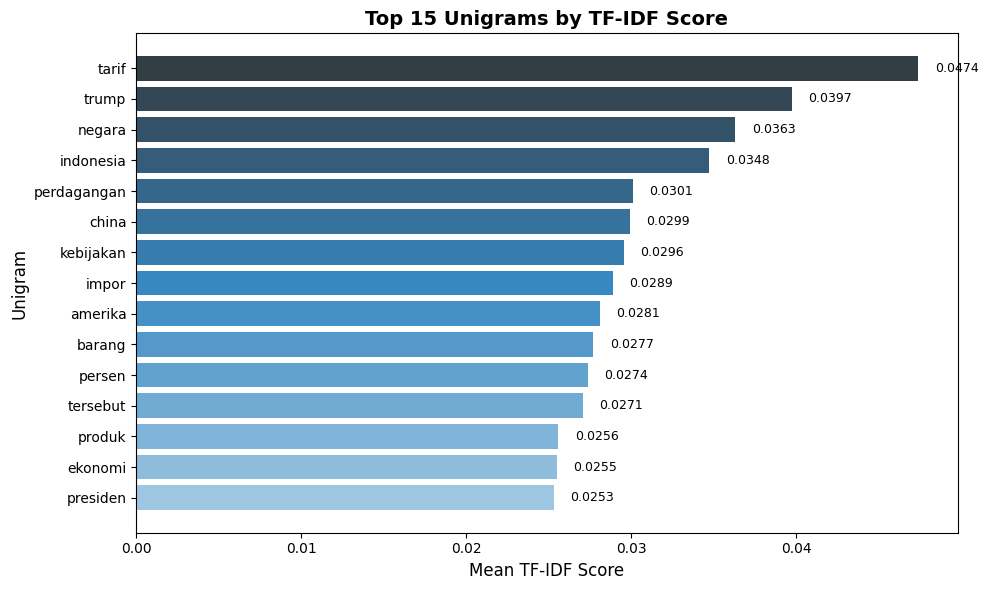

In [135]:
plot_tfidf_ngram(df_unigrams_tfidf, 'Unigram', 'Blues_d', PLOT_TOP_K)

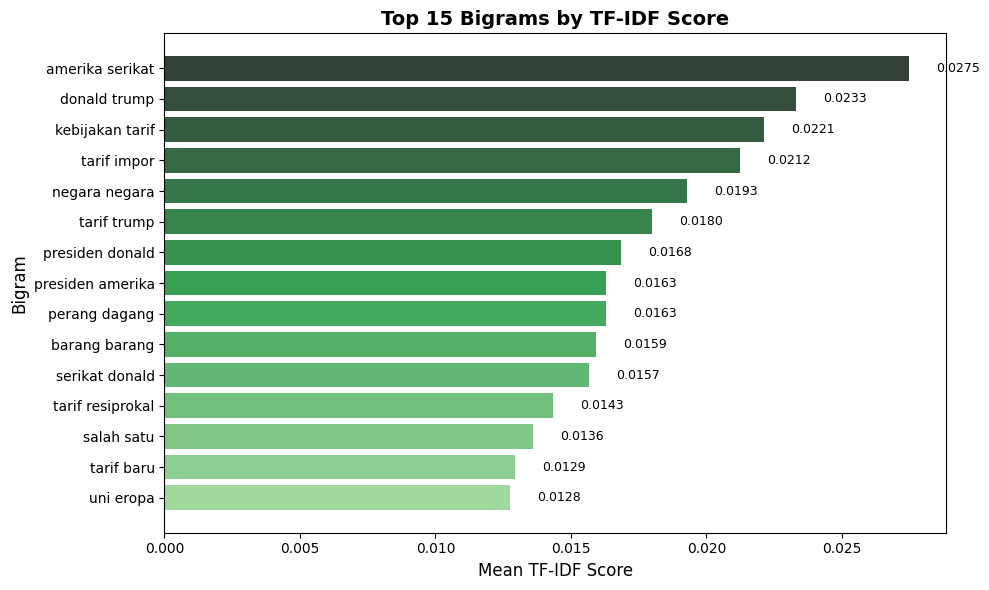

In [136]:
plot_tfidf_ngram(df_bigrams_tfidf, 'Bigram', 'Greens_d', PLOT_TOP_K)

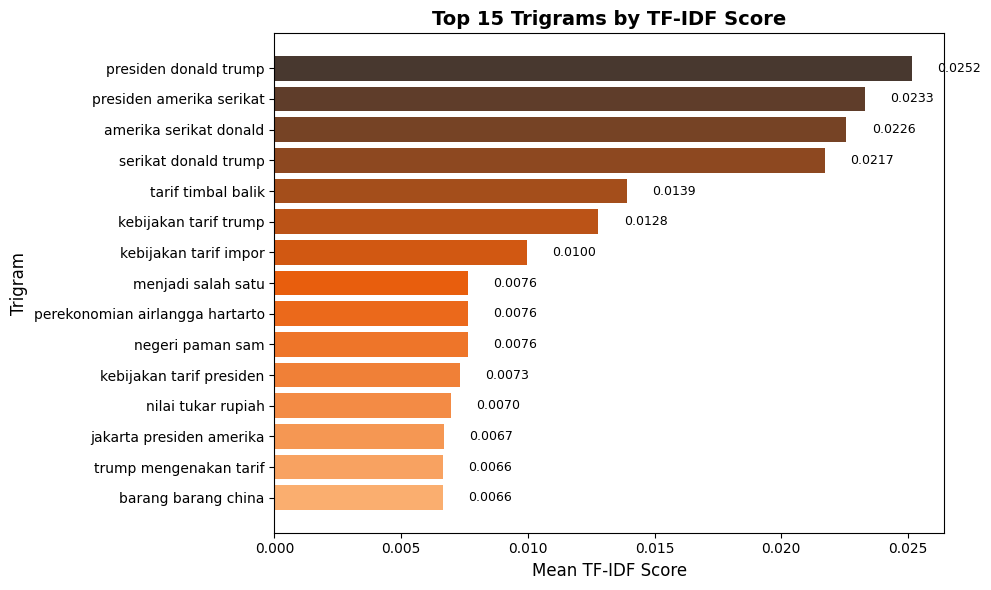

In [137]:
plot_tfidf_ngram(df_trigrams_tfidf, 'Trigram', 'Oranges_d', PLOT_TOP_K)

### 6.1 Combined Overview Chart

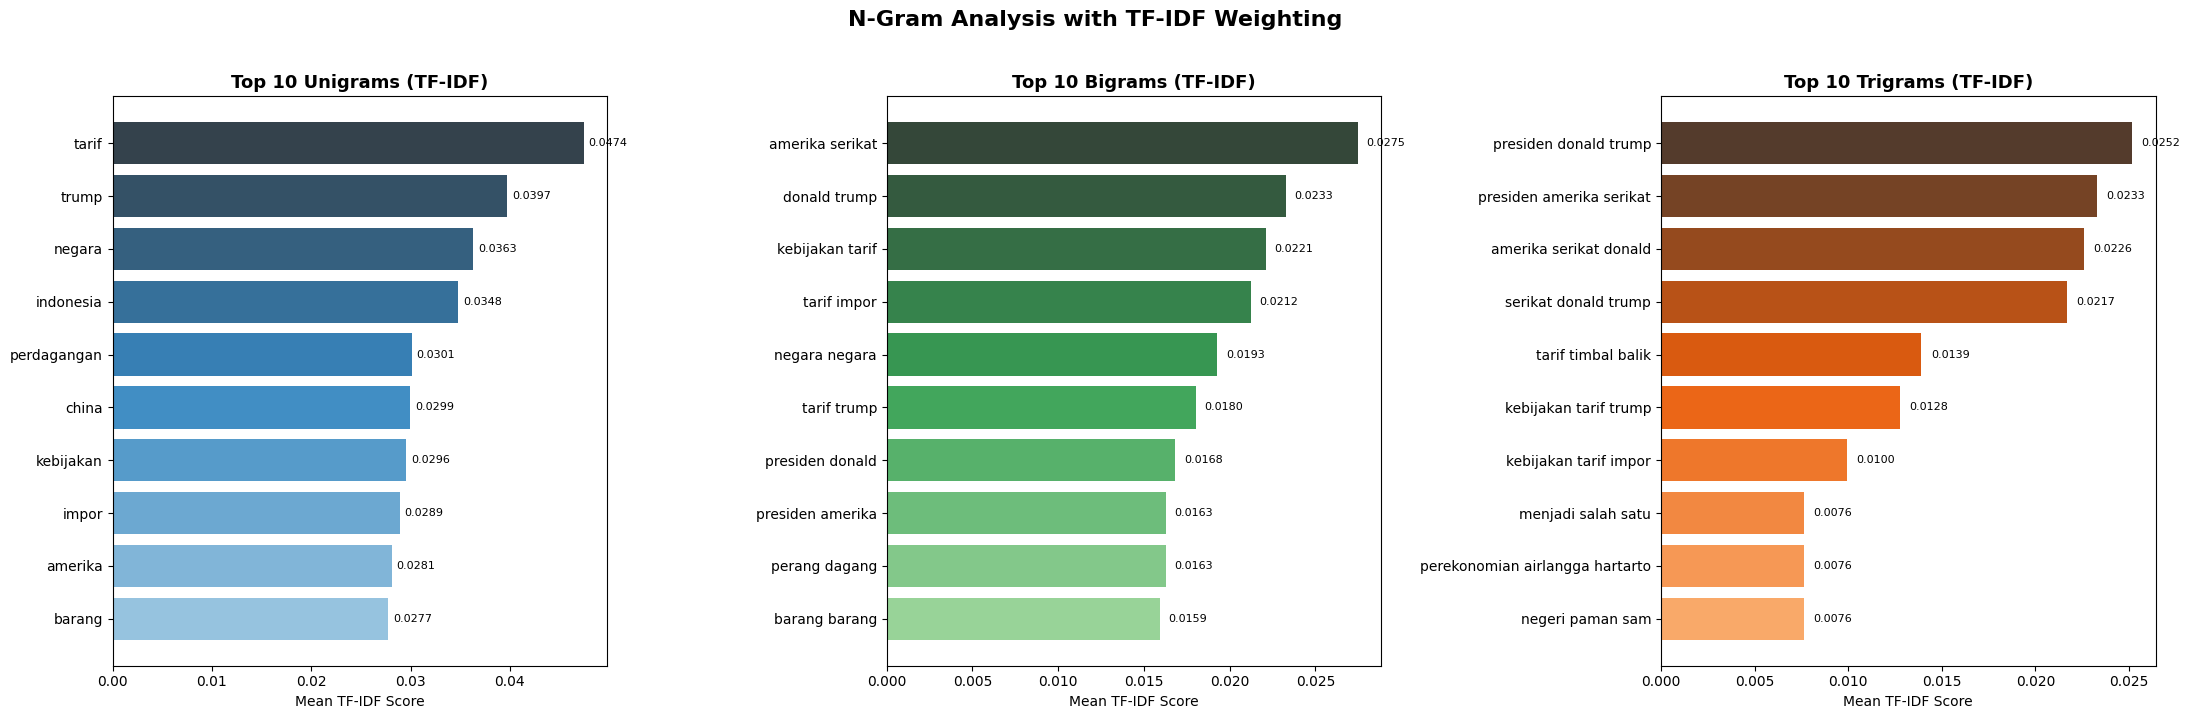

In [138]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

datasets = [
    (df_unigrams_tfidf, 'Unigram', 'Blues_d'),
    (df_bigrams_tfidf, 'Bigram', 'Greens_d'),
    (df_trigrams_tfidf, 'Trigram', 'Oranges_d')
]

for ax, (df_tfidf, label, palette) in zip(axes, datasets):
    top_10 = df_tfidf.head(10).iloc[::-1]
    colors = sns.color_palette(palette, len(top_10))
    ax.barh(top_10['N-gram'], top_10['TF-IDF Score'], color=colors)
    ax.set_title(f'Top 10 {label}s (TF-IDF)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Mean TF-IDF Score')

    for i, val in enumerate(top_10['TF-IDF Score']):
        ax.text(val + 0.0005, i, f'{val:.4f}', va='center', fontsize=8)

plt.suptitle('N-Gram Analysis with TF-IDF Weighting', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 7. TF-IDF N-Gram Analysis by Sentiment Category

Compare the top TF-IDF N-grams across different sentiment categories to identify framing differences.

In [139]:
# Check if sentiment column exists
sentiment_col = None
for col in ['Sentiment', 'sentiment', 'manual_sentiment']:
    if col in selected_df.columns:
        sentiment_col = col
        break

if sentiment_col:
    sentiments = selected_df[sentiment_col].dropna().unique()
    print(f"Sentiment column found: '{sentiment_col}'")
    print(f"Categories: {list(sentiments)}")
    print(f"Distribution:")
    print(selected_df[sentiment_col].value_counts())
else:
    print("No sentiment column found. Skipping sentiment-based analysis.")

No sentiment column found. Skipping sentiment-based analysis.


In [140]:
if sentiment_col:
    print("\n" + "=" * 60)
    print("TF-IDF BIGRAM ANALYSIS BY SENTIMENT")
    print("=" * 60)
    
    sentiment_bigrams = {}
    
    for sentiment in sorted(sentiments):
        subset = selected_df[selected_df[sentiment_col] == sentiment]
        if len(subset) < 2:
            print(f"\nSkipping '{sentiment}' (only {len(subset)} article(s))")
            continue
        
        sub_corpus = subset['cleaned_text'].tolist()
        df_bg, _, _ = tfidf_ngram_analysis(sub_corpus, (2, 2), 10)
        sentiment_bigrams[sentiment] = df_bg
        
        print(f"\n--- Sentiment: {sentiment} ({len(subset)} articles) ---")
        print(df_bg.to_string())

In [141]:
# Visualize sentiment-based bigram comparison
if sentiment_col and len(sentiment_bigrams) >= 2:
    n_sentiments = len(sentiment_bigrams)
    fig, axes = plt.subplots(1, n_sentiments, figsize=(8 * n_sentiments, 7))
    
    if n_sentiments == 1:
        axes = [axes]
    
    color_map = {
        'positif': 'Greens_d', 'positive': 'Greens_d',
        'negatif': 'Reds_d', 'negative': 'Reds_d',
        'netral': 'Blues_d', 'neutral': 'Blues_d'
    }
    
    for ax, (sentiment, df_bg) in zip(axes, sorted(sentiment_bigrams.items())):
        top_10 = df_bg.head(10).iloc[::-1]
        palette = color_map.get(sentiment.lower(), 'Purples_d')
        colors = sns.color_palette(palette, len(top_10))
        
        ax.barh(top_10['N-gram'], top_10['TF-IDF Score'], color=colors)
        ax.set_title(f'Top Bigrams: {sentiment.capitalize()}\n({len(selected_df[selected_df[sentiment_col] == sentiment])} articles)',
                     fontsize=13, fontweight='bold')
        ax.set_xlabel('Mean TF-IDF Score')
        
        for i, val in enumerate(top_10['TF-IDF Score']):
            ax.text(val + 0.0005, i, f'{val:.4f}', va='center', fontsize=8)
    
    plt.suptitle('TF-IDF Bigram Comparison by Sentiment', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

## 8. Per-Article TF-IDF N-Gram Comparison (Optional)

For each individual article, we compute its top N-grams by TF-IDF score (using the corpus-level IDF).

In [142]:
if len(selected_df) > 1 and len(selected_df) <= 50:
    # Fit a bigram vectorizer on the full corpus
    vec_bg = TfidfVectorizer(ngram_range=(2, 2), max_features=10000, sublinear_tf=True)
    tfidf_mat = vec_bg.fit_transform(corpus)
    features = vec_bg.get_feature_names_out()
    
    print("Per-article top 5 bigrams (by TF-IDF score):")
    print("=" * 60)
    
    for i, (idx, row) in enumerate(selected_df.iterrows()):
        scores = tfidf_mat[i].toarray().flatten()
        top_indices = scores.argsort()[-5:][::-1]
        
        title = row.get('judul', row.get('title', f'Article {i}'))
        no = row.get('no', row.get('No', i))
        print(f"\nArticle [{no}]: {str(title)[:60]}")
        for j in top_indices:
            if scores[j] > 0:
                print(f"    {features[j]:35s}  (TF-IDF: {scores[j]:.4f})")
elif len(selected_df) > 50:
    print(f"Too many articles ({len(selected_df)}) for per-article comparison. Skipping.")
else:
    print("Only one article selected. Skipping per-article comparison.")

Too many articles (999) for per-article comparison. Skipping.


## 9. Summary

In [143]:
print("=" * 60)
print("TF-IDF N-GRAM ANALYSIS SUMMARY")
print("=" * 60)
print(f"Articles analyzed        : {len(selected_df)}")
print(f"Total tokens (cleaned)   : {selected_df['token_count'].sum()}")
print(f"Stemming applied         : {USE_STEMMING}")
print(f"Selection mode           : {SELECTION_MODE}")
print(f"Weighting method         : TF-IDF (sublinear_tf=True)")
print()
print("Top 5 Unigrams (TF-IDF):")
for _, row in df_unigrams_tfidf.head(5).iterrows():
    print(f"    {row['N-gram']:30s}  (score: {row['TF-IDF Score']:.4f})")
print()
print("Top 5 Bigrams (TF-IDF):")
for _, row in df_bigrams_tfidf.head(5).iterrows():
    print(f"    {row['N-gram']:30s}  (score: {row['TF-IDF Score']:.4f})")
print()
print("Top 5 Trigrams (TF-IDF):")
for _, row in df_trigrams_tfidf.head(5).iterrows():
    print(f"    {row['N-gram']:30s}  (score: {row['TF-IDF Score']:.4f})")

TF-IDF N-GRAM ANALYSIS SUMMARY
Articles analyzed        : 999
Total tokens (cleaned)   : 405219
Stemming applied         : False
Selection mode           : all
Weighting method         : TF-IDF (sublinear_tf=True)

Top 5 Unigrams (TF-IDF):
    tarif                           (score: 0.0474)
    trump                           (score: 0.0397)
    negara                          (score: 0.0363)
    indonesia                       (score: 0.0348)
    perdagangan                     (score: 0.0301)

Top 5 Bigrams (TF-IDF):
    amerika serikat                 (score: 0.0275)
    donald trump                    (score: 0.0233)
    kebijakan tarif                 (score: 0.0221)
    tarif impor                     (score: 0.0212)
    negara negara                   (score: 0.0193)

Top 5 Trigrams (TF-IDF):
    presiden donald trump           (score: 0.0252)
    presiden amerika serikat        (score: 0.0233)
    amerika serikat donald          (score: 0.0226)
    serikat donald trump         

## 10. Export Results to CSV

In [144]:
import os

OUTPUT_DIR = "../outputs/ngram_tfidf"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ---- 1. Export top N-grams (unigram, bigram, trigram) ----
df_unigrams_tfidf.to_csv(f"{OUTPUT_DIR}/top_unigrams_tfidf.csv", index=True)
df_bigrams_tfidf.to_csv(f"{OUTPUT_DIR}/top_bigrams_tfidf.csv", index=True)
df_trigrams_tfidf.to_csv(f"{OUTPUT_DIR}/top_trigrams_tfidf.csv", index=True)

print(f"Exported: top_unigrams_tfidf.csv  ({len(df_unigrams_tfidf)} rows)")
print(f"Exported: top_bigrams_tfidf.csv   ({len(df_bigrams_tfidf)} rows)")
print(f"Exported: top_trigrams_tfidf.csv  ({len(df_trigrams_tfidf)} rows)")

Exported: top_unigrams_tfidf.csv  (300 rows)
Exported: top_bigrams_tfidf.csv   (300 rows)
Exported: top_trigrams_tfidf.csv  (300 rows)


In [145]:
# ---- 2. Export combined N-grams into one file ----
df_uni = df_unigrams_tfidf.copy()
df_uni['Type'] = 'Unigram'
df_bi = df_bigrams_tfidf.copy()
df_bi['Type'] = 'Bigram'
df_tri = df_trigrams_tfidf.copy()
df_tri['Type'] = 'Trigram'

df_combined = pd.concat([df_uni, df_bi, df_tri], ignore_index=True)
df_combined.to_csv(f"{OUTPUT_DIR}/all_ngrams_tfidf_combined.csv", index=False)
print(f"Exported: all_ngrams_tfidf_combined.csv  ({len(df_combined)} rows)")

Exported: all_ngrams_tfidf_combined.csv  (900 rows)


In [146]:
# # ---- 3. Export N-grams per sentiment category ----
# if sentiment_col and len(sentiment_bigrams) > 0:
#     all_sentiment_rows = []
    
#     for sentiment, df_bg in sentiment_bigrams.items():
#         temp = df_bg.copy()
#         temp['Sentiment'] = sentiment
#         all_sentiment_rows.append(temp)
    
#     df_sentiment_export = pd.concat(all_sentiment_rows, ignore_index=True)
#     df_sentiment_export.to_csv(f"{OUTPUT_DIR}/bigrams_tfidf_by_sentiment.csv", index=False)
#     print(f"Exported: bigrams_tfidf_by_sentiment.csv  ({len(df_sentiment_export)} rows)")
# else:
#     print("No sentiment-based data to export.")

In [147]:
# # ---- 4. Export full TF-IDF matrix (all bigrams, all documents) ----
# # Complete TF-IDF score for every bigram in every article.
# # Useful for further analysis or paper appendix.

# EXPORT_FULL_MATRIX = True  # Set False if not needed (file can be large)

# if EXPORT_FULL_MATRIX:
#     vec_full = TfidfVectorizer(ngram_range=(2, 2), max_features=5000, sublinear_tf=True)
#     mat_full = vec_full.fit_transform(corpus)
#     feat_full = vec_full.get_feature_names_out()
    
#     df_matrix = pd.DataFrame(
#         mat_full.toarray(),
#         columns=feat_full
#     )
    
#     # Add article metadata
#     no_col = 'no' if 'no' in selected_df.columns else 'No'
#     title_col = 'judul' if 'judul' in selected_df.columns else 'title'
    
#     if no_col in selected_df.columns:
#         df_matrix.insert(0, 'article_no', selected_df[no_col].values)
#     if title_col in selected_df.columns:
#         df_matrix.insert(1 if no_col in selected_df.columns else 0, 'article_title', selected_df[title_col].values)
    
#     df_matrix.to_csv(f"{OUTPUT_DIR}/full_bigram_tfidf_matrix.csv", index=False)
#     print(f"Exported: full_bigram_tfidf_matrix.csv  ({df_matrix.shape[0]} articles x {len(feat_full)} bigrams)")
# else:
#     print("Full matrix export skipped (EXPORT_FULL_MATRIX = False).")

In [148]:
# # ---- Final summary of exported files ----
# print()
# print("=" * 60)
# print("EXPORTED FILES")
# print("=" * 60)
# for f in sorted(os.listdir(OUTPUT_DIR)):
#     fpath = os.path.join(OUTPUT_DIR, f)
#     size_kb = os.path.getsize(fpath) / 1024
#     print(f"  {f:45s}  ({size_kb:.1f} KB)")
# print(f"\nAll files saved to: {os.path.abspath(OUTPUT_DIR)}")